# Inciso 4 y 5

### Librerías importadas.

In [1]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
import math
from sklearn.metrics import f1_score, classification_report, roc_auc_score, ConfusionMatrixDisplay

### Importación de datos.

In [2]:
df = pd.read_csv('datos_predictores.csv')
df.head(2)

,lago,x,y,b03,b04,b05,b08,ndci,ndvi,ndwi,proporcion_agua,proporcion_tierra,proporcion_otro,chl_a_estimada,pixeles_validos,alta_cianobacteria,dia,mes,anio
0,amatitlan,754575.0,1594635.0,0.1447,0.1524,0.1380,0.1706,-0.049587,0.056347,-0.082144,0.0,0.0,1.0,2.594255,1,0,28,1,2025
1,amatitlan,754595.0,1594635.0,0.1355,0.1436,0.1368,0.1617,-0.024251,0.059286,-0.088156,0.0,0.0,1.0,3.494680,1,0,28,1,2025


### Valores faltantes.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16735977 entries, 0 to 16735976
Data columns (total 19 columns):
 #   Column              Dtype  
---  ------              -----  
 0   lago                object 
 1   x                   float64
 2   y                   float64
 3   b03                 float64
 4   b04                 float64
 5   b05                 float64
 6   b08                 float64
 7   ndci                float64
 8   ndvi                float64
 9   ndwi                float64
 10  proporcion_agua     float64
 11  proporcion_tierra   float64
 12  proporcion_otro     float64
 13  chl_a_estimada      float64
 14  pixeles_validos     int64  
 15  alta_cianobacteria  int64  
 16  dia                 int64  
 17  mes                 int64  
 18  anio                int64  
dtypes: float64(13), int64(5), object(1)
memory usage: 2.4+ GB


No hay valores faltantes.

### Muestra de datos

In [4]:
proporcion = 0.01
df, _ = train_test_split(df, train_size=proporcion, stratify=df["alta_cianobacteria"], random_state=0)
df = df.reset_index(drop=True)

In [5]:
df.shape

(167359, 19)

### Etiquetas y variable objetivo.

In [6]:
# Eliminar la variable objetivo y cualquier variable que cause fuga de información.
# Se elimina la variable lago, ya que solo se desea predecir en base a los demás atributos de mediciones.
X = df.drop(columns=['lago', 'alta_cianobacteria', 'ndci', 'chl_a_estimada', 'b04', 'b05'], errors="ignore")
y = df['alta_cianobacteria'].astype(int)

### Conjunto de entrenamiento y prueba.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

### Observando las distribuciones.

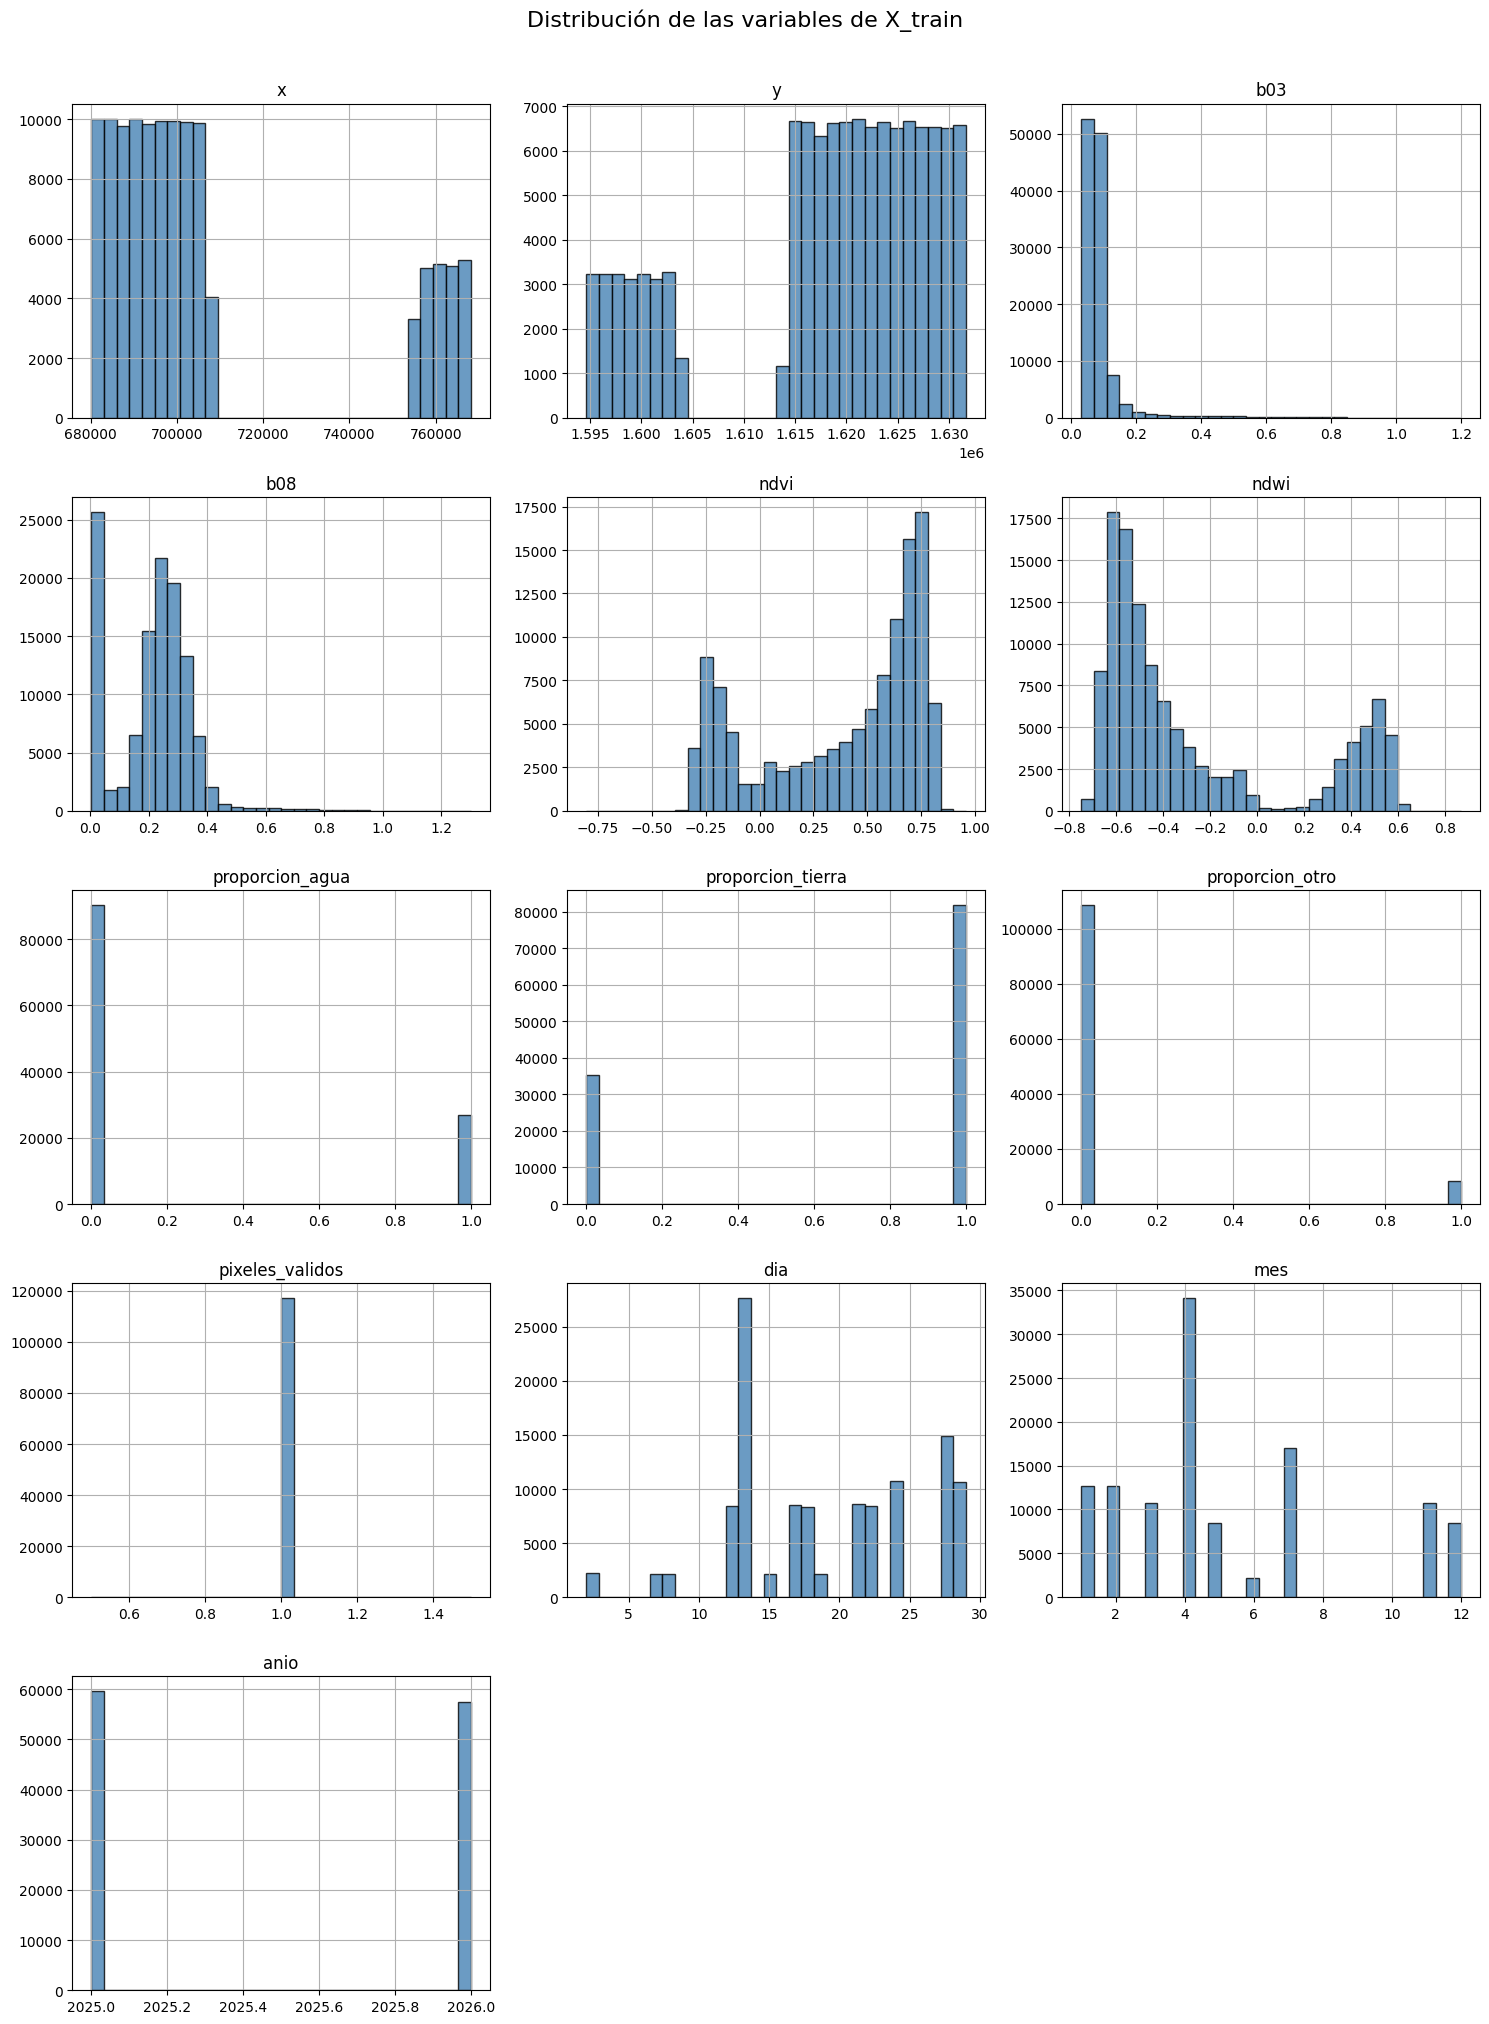

In [8]:
n_columnas = 3
n_filas = math.ceil(X_train.shape[1] / n_columnas)

X_train.hist(bins=30, figsize=(15, 4 * n_filas), layout=(n_filas, n_columnas), color="steelblue", edgecolor="black", alpha=0.8)
plt.suptitle("Distribución de las variables de X_train", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

Debido a que los rangos de las distribuciones no son amplios, relativamente, se usará MinMaxScaler.

## Regresión logística.

### Preprocesamiento a utilizar.

In [9]:
pipeline_rl = Pipeline(steps=[("minmax_scaler", MinMaxScaler()),
                                   ("modelo", LogisticRegression(max_iter=1000, random_state=0))])

### Rejilla de hiperparámetros.

In [10]:
#rejilla_rl = [
#    {
#        "modelo__solver": ["liblinear"],
#        "modelo__penalty": ["l1", "l2"],
#        "modelo__C": [0.01, 0.1, 1, 10]
#    },
#    {
#        "modelo__solver": ["lbfgs"],
#        "modelo__penalty": ["l2"],
#        "modelo__C": [0.01, 0.1, 1, 10]
#    }
#]

rejilla_rl = [{'modelo__C': [10], 'modelo__penalty': ['l2'], 'modelo__solver': ['liblinear']}]

### GridSearch.

In [11]:
grid_search_rl = GridSearchCV(
    estimator=pipeline_rl,
    param_grid=rejilla_rl,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

### Entrenamiento del modelo.

In [12]:
grid_search_rl.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,Pipeline(step...om_state=0))])
,param_grid,"[{'modelo__C': [10], 'modelo__penalty': ['l2'], 'modelo__solver': ['liblinear']}]"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


### Mejor modelo e hiperparámetros.

In [13]:
print("Mejores hiperparámetros:", grid_search_rl.best_params_)
print("Mejor accuracy promedio en validación:", grid_search_rl.best_score_)

mejor_lr = grid_search_rl.best_estimator_

Mejores hiperparámetros: {'modelo__C': 10, 'modelo__penalty': 'l2', 'modelo__solver': 'liblinear'}
Mejor accuracy promedio en validación: 0.8771142148035093


## Random Forest.

### Preprocesamiento a utilizar.

In [14]:
pipeline_rf = Pipeline(steps=[("preprocesamiento", MinMaxScaler(feature_range=(0, 1))),
                              ("modelo", RandomForestClassifier(random_state=42))])

### Rejilla de hiperparámetros.

In [15]:
#rejilla_rf = {
#    "modelo__n_estimators": [50, 100, 200],
#    "modelo__max_depth": [3, 5, 7],
#    "modelo__min_samples_split": [2, 5, 8],
#    "modelo__min_samples_leaf": [1, 2, 4],
#    "modelo__max_features": ["sqrt", "log2"]
#}
rejilla_rf = {
    "modelo__n_estimators": [200],
    "modelo__max_depth": [7],
    "modelo__min_samples_split": [5],
    "modelo__min_samples_leaf": [1],
    "modelo__max_features": ["sqrt"]
}


### GridSearch.

In [16]:
grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=rejilla_rf,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

### Entrenamiento del modelo.

In [17]:
grid_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'modelo__max_depth': [7], 'modelo__max_features': ['sqrt'], 'modelo__min_samples_leaf': [1], 'modelo__min_samples_split': [5], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


### Mejor modelo e hiperparámetros.

In [18]:
print("Mejores hiperparámetros:", grid_search_rf.best_params_)
print("Mejor accuracy en validación:", grid_search_rf.best_score_)
mejor_rf = grid_search_rf.best_estimator_

Mejores hiperparámetros: {'modelo__max_depth': 7, 'modelo__max_features': 'sqrt', 'modelo__min_samples_leaf': 1, 'modelo__min_samples_split': 5, 'modelo__n_estimators': 200}
Mejor accuracy en validación: 0.8817962378657848


## XGBoost

### Preprocesamiento a utilizar.

In [19]:
pipeline_xgb = Pipeline(steps=[
    ("preprocesamiento", MinMaxScaler(feature_range=(0, 1))),
    ("modelo", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=0,
        n_jobs=1
    ))
])

### Rejilla de hiperparámetros.

In [20]:
#rejilla_xgb = {
#    "modelo__n_estimators": [100, 200, 300],
#    "modelo__max_depth": [3, 5, 7],
#    "modelo__learning_rate": [0.01, 0.1, 0.2],
#    "modelo__subsample": [0.8, 1.0],
#    "modelo__colsample_bytree": [0.8, 1.0]
#}
rejilla_xgb = {
    "modelo__n_estimators": [300],
    "modelo__max_depth": [5],
    "modelo__learning_rate": [0.1],
    "modelo__subsample": [1.0],
    "modelo__colsample_bytree": [1.0]
}

### GridSearch.

In [21]:
grid_search_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=rejilla_xgb,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

### Entrenamiento del modelo.

In [22]:
grid_search_xgb.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'modelo__colsample_bytree': [1.0], 'modelo__learning_rate': [0.1], 'modelo__max_depth': [5], 'modelo__n_estimators': [300], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,feature_range,"(0, ...)"


### Mejor modelo e hiperparámetros.

In [23]:
mejor_xgb = grid_search_xgb.best_estimator_
print("Mejor accuracy en validación:", grid_search_xgb.best_score_)
print("Mejores hiperparámetros:", grid_search_xgb.best_params_)

Mejor accuracy en validación: 0.9006115695061
Mejores hiperparámetros: {'modelo__colsample_bytree': 1.0, 'modelo__learning_rate': 0.1, 'modelo__max_depth': 5, 'modelo__n_estimators': 300, 'modelo__subsample': 1.0}


## Elección de hiperparámetros.

$\textbf{Regresión logística}$  
C: Se usa para evitar el sobreajuste. [0.01, 0.1, 1, 10].  
penalty: Técnica usada para evitar el sobreajuste. [l1, l2].  
solver: Algoritmo optimizador. [liblinear, lbfgs].  


$\textbf{Random Forest}$  
n_estimators: Cantidad de árboles. [50, 100, 200].  
max_depth": Profundida máxima de árboles. [3, 5, 7].  
min_samples_split: Número de muestras mínimo para ser dividido. [2, 5, 8].  
min_samples_leaf: Mínimo de muestras que debe tener una hoja [1, 2, 4].  
max_features: Cantidad máxima de características [sqrt, log2].  


$\textbf{XGBoost}$
n_estimators: Cantidad de árboles construidos secuencialmente. [100, 200, 300].
max_depth: Máxima profundidad de cada árbol [3, 5, 7].
learning_rate: Determina cuánto contribuye cada nuevo árbol al modelo. [0.01, 0.1, 0.2].
subsample: Proporción de filas utilizadas para entrenar cada árbol. [0.8, 1.0].
colsample_bytree: Proporción de variables utilizadas para construir cada árbol. [0.8, 1.0].


Se usará el F1 score como la métrica con la que se elige el mejor modelo, esto debido a que le dará la misma importancia a falsos positivos como falsos negativos, sin importar el desbalance.

## Evaluación en el conjunto de prueba.

In [24]:
y_pred_rl = mejor_lr.predict(X_test)
y_pred_rf = mejor_rf.predict(X_test)
y_pred_xgb = mejor_xgb.predict(X_test)

# Cálculo del F1 score
f1_rl = f1_score(y_test, y_pred_rl, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)
f1_xgb = f1_score(y_test, y_pred_xgb, zero_division=0)

# Tabla comparativa
resultados_f1 = pd.DataFrame({
    "Modelo": ["Regresión logística", "Random Forest", "XGBoost"],
    "F1 score": [f1_rl, f1_rf, f1_xgb]
}).sort_values("F1 score", ascending=False).reset_index(drop=True)

display(resultados_f1)

,Modelo,F1 score
0,XGBoost,0.900120
1,Random Forest,0.881598
2,Regresión logística,0.877329


Con el criterio de F1 score, se toma como el mejor modelo el XGBoost.

### Reporte de clasificación.

In [36]:
print('           Reporte de Regresión Logística               ')
print('--------------------------------------------------------')
print(classification_report(y_test, y_pred_rl, target_names=["Baja presencia", "Alta presencia"], digits=4, zero_division=0))

           Reporte de Regresión Logística               
--------------------------------------------------------
                precision    recall  f1-score   support

Baja presencia     0.9397    0.9047    0.9218     31250
Alta presencia     0.8520    0.9043    0.8773     18958

      accuracy                         0.9045     50208
     macro avg     0.8958    0.9045    0.8996     50208
  weighted avg     0.9066    0.9045    0.9050     50208



In [37]:
print('               Reporte de Random Forest                 ')
print('--------------------------------------------------------')
print(classification_report(y_test, y_pred_rf, target_names=["Baja presencia", "Alta presencia"], digits=4, zero_division=0))

               Reporte de Random Forest                 
--------------------------------------------------------
                precision    recall  f1-score   support

Baja presencia     0.9401    0.9107    0.9251     31250
Alta presencia     0.8600    0.9043    0.8816     18958

      accuracy                         0.9083     50208
     macro avg     0.9000    0.9075    0.9034     50208
  weighted avg     0.9098    0.9083    0.9087     50208



In [38]:
print('                  Reporte de XGBoost                    ')
print('--------------------------------------------------------')
print(classification_report(y_test, y_pred_xgb, target_names=["Baja presencia", "Alta presencia"], digits=4, zero_division=0))

                  Reporte de XGBoost                    
--------------------------------------------------------
                precision    recall  f1-score   support

Baja presencia     0.9451    0.9315    0.9382     31250
Alta presencia     0.8897    0.9108    0.9001     18958

      accuracy                         0.9237     50208
     macro avg     0.9174    0.9211    0.9192     50208
  weighted avg     0.9242    0.9237    0.9238     50208



El XGBoost fue superior en precision, recall y en f1-score para cada una de las clases.

### ROC-AUC.

In [39]:
y_proba_lr = mejor_lr.predict_proba(X_test)[:, 1]

print("Regresion logística")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.4f}")

Regresion logística
ROC-AUC: 0.9692


In [40]:
y_proba_rf = mejor_rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

Random Forest
ROC-AUC: 0.9717


In [41]:
y_proba_xgb = mejor_xgb.predict_proba(X_test)[:, 1]

print("XGBoost")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

XGBoost
ROC-AUC: 0.9801


XGBoost también presentó un mayor ROC-AUC que los otros modelos, por lo que comete menos errores que los otros.

### Matrices de confusión.

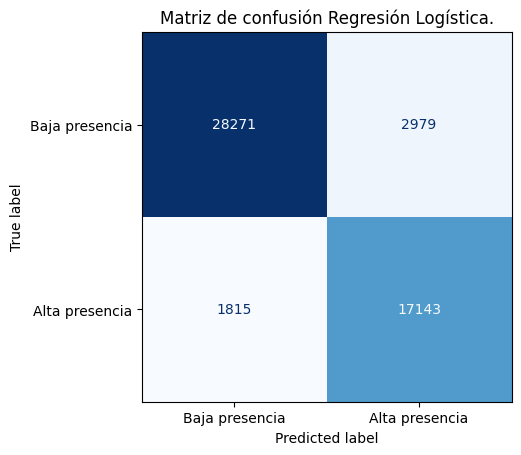

In [42]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rl, display_labels=["Baja presencia", "Alta presencia"],
                                        cmap="Blues", colorbar=False)
plt.title(f"Matriz de confusión Regresión Logística.")
plt.show()

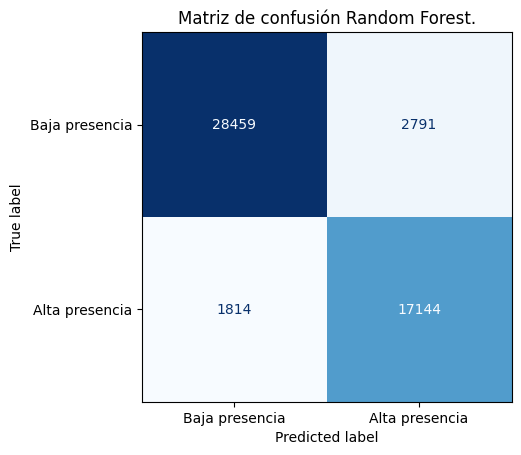

In [43]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, display_labels=["Baja presencia", "Alta presencia"],
                                        cmap="Blues", colorbar=False)
plt.title(f"Matriz de confusión Random Forest.")
plt.show()

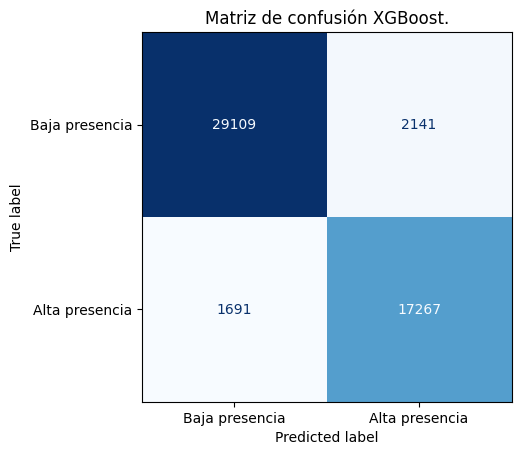

In [44]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, display_labels=["Baja presencia", "Alta presencia"],
                                        cmap="Blues", colorbar=False)
plt.title(f"Matriz de confusión XGBoost.")
plt.show()

XGBoost mostró ser mejor que los otros modelos y en todos los modelos se tiene un fallo similar respecto a ambas etiquetas.

### 5.2) Comparación de resultados.

En todas las métricas y en la matriz de confusión analizadas el mejor modelo fue el XGBoost, el cual demostró tener una mejor capacidad de predicción. El resultado tampoco fue mucho mejor que los otros modelos, por lo que si se requier explicabilidad, la regresión logística puede ser una excelente opción, ya que tiene un f1-score solo 0.023 por debajo del XGBoost.

### 5.3) 
Desde el punto de vista ambiental, analice las consecuencias de clasificar una zona sin alta presencia como alta presencia y de no detectar una zona que sí presenta alta presencia de cianobacteria. Determine cuál de estos errores considera más importante reducir y teniendo en cuenta esto compare los modelos usando la métrica más adecuada.  

Si se desea generar un plan de limpieza, catalogar incorrectamente una zona de baja presencia como si fuera de alta presencia, puede generar inversión más elevada de la necesaria para los procesos de limpieza. El caso contrario, puede evitar que zonas realmente afectadas sean consideradas para la limpieza, generando aún más acumulación elevada que no sea tratada, generando así problemas para la salud de las poblaciones cercanas o la flora y fauna.
Consideramos que se debe dar más importancia a no predecir incorrectamente las zonas de alta presencia, ya que estas pueden ocasionar problemas de salud o de pérdida de flora y fauna. La métrica más útil sería el recall, (tomando alta presencia como positiva), en este caso el modelo XGBoost es considerado el mejor.